In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm import tqdm
from typing import Callable
from importlib import reload
import torchvision.transforms.v2 as v2
import matplotlib
import torchvision

SEED, STEPS, BATCH_SIZE = 42, 4000, 256
NOISE = 0.06  # Шум в координатах после деления на 10.
DEVICE = "auto"  # "auto", "cpu", "cuda:0", "cuda:1", ...
if DEVICE == "auto":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = torch.device(DEVICE)
if device.type == "cuda" and not torch.cuda.is_available():
    raise RuntimeError('CUDA недоступна: выберите DEVICE = "cpu" или "auto".')
torch.manual_seed(SEED)
torch.set_num_threads(2)  # Для маленьких MLP на CPU.
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
device_name = torch.cuda.get_device_name(device) if device.type == "cuda" else "CPU"
if (torch.xpu.is_available() and device_name == "CPU"):
    device_name = torch.xpu.get_device_name(0)
print(f"PyTorch {torch.__version__} | {device} ({device_name}) | seed={SEED}")

PyTorch 2.14.1+cpu | cpu (CPU) | seed=42


In [51]:
img_w, img_h, chanels = 64, 48, 1

In [61]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Grayscale(1),
    v2.Resize([img_h, img_w]),
    v2.Normalize((0.5,), (0.5,))
])


In [62]:
dataset = torchvision.datasets.ImageFolder("data/badapple", transform=transform)

In [64]:
batch_size = 32
val_batch_size = 256

trainset, valset = torch.utils.data.random_split(dataset, lengths=[0.95, 0.05])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=4)

valloader = torch.utils.data.DataLoader(valset, batch_size=val_batch_size, shuffle=True, num_workers=4)


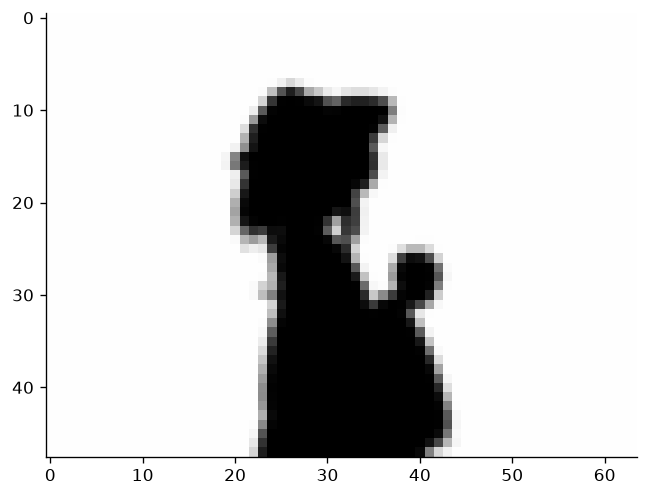

torch.Size([1, 48, 64])


In [84]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, _ = next(dataiter)
# print(images, labels)
# show images
imshow(torchvision.utils.make_grid(images[0]))
print(images[0].shape)
# print()

In [66]:
import nice_model
reload(nice_model)

hid_width = 500

mid = lambda in_w, out_w: nn.Sequential(
    nn.Linear(in_w, hid_width),
    nn.ReLU(),
    nn.Linear(hid_width, hid_width), 
    nn.ReLU(), 
    nn.Linear(hid_width, hid_width),
    nn.ReLU(), 
    nn.Linear(hid_width, hid_width),
    nn.ReLU(), 
    nn.Linear(hid_width, hid_width),
    nn.ReLU(),
    nn.Linear(hid_width, out_w)
)

spliters = [nice_model.BaseSpliter(i%2, n=img_w * img_h * chanels) for i in range(8)]

model = nice_model.NICE(mid_model=mid, width=img_w * img_h * chanels, spliter_list=spliters)

In [102]:
history = []
def record(step, model: nn.Module):
    with torch.no_grad():
        X, _ = next(iter(valloader))
        X = X.flatten(start_dim=1)
        with torch.no_grad():
            valscore = nice_model.loss_function(model(X), model.jacobian_det())
        X, _ = next(iter(trainloader))
        X = X.flatten(start_dim=1)
        with torch.no_grad():
            trainscore = nice_model.loss_function(model(X), model.jacobian_det())
        history.append([step, valscore, trainscore])

optimizer = torch.optim.AdamW(model.parameters())
steps = 0
for epoch in range(20):
    for X, _ in tqdm(trainloader):
        optimizer.zero_grad()
        X = X.flatten(start_dim=1)
        loss = nice_model.loss_function(model(X), model.jacobian_det())
        loss.backward()
        optimizer.step()
        if steps % 100 == 0:
            record(steps, model)
        steps += 1


100%|██████████| 196/196 [00:30<00:00,  6.33it/s]


In [54]:
valset.attr.shape

torch.Size([19867, 40])

In [68]:
def sample(n: int):
    res = torch.randn(n, img_h * img_w * chanels)
    with torch.no_grad():
        res = model.inverse(res)
    return res.reshape(n, chanels, img_h, img_w)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.43655223..1.3965104].


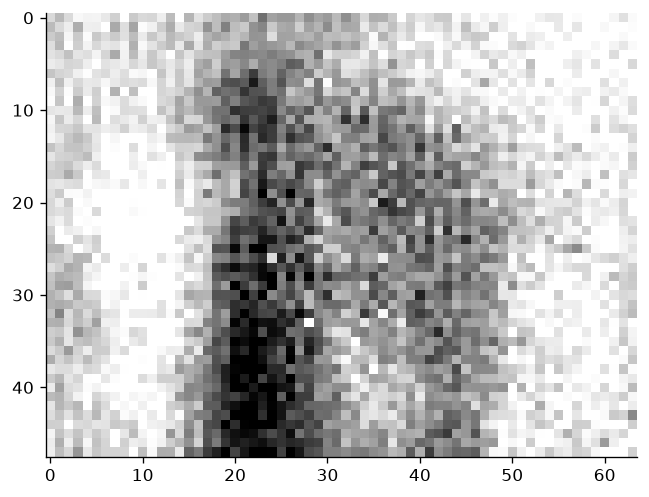

In [123]:
imgs = sample(1)
imshow(torchvision.utils.make_grid(imgs[0]))

In [88]:
record(0, model)

In [74]:
X, _ = next(iter(valloader))
X.shape

torch.Size([256, 3, 64, 64])

In [103]:
history = np.array(history)

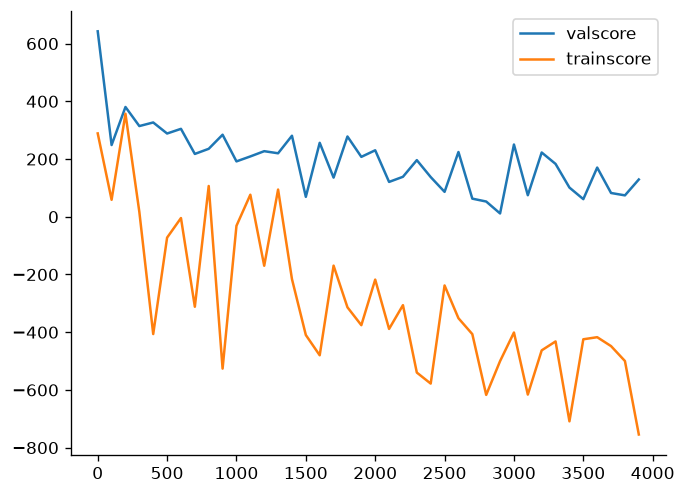

In [104]:
fig, ax = plt.subplots()

ax.plot(history[:, 0], history[:, 1], label="valscore")
ax.plot(history[:, 0], history[:, 2], label="trainscore")
ax.legend()
plt.show()

In [96]:
history.shape

(1, 3)

In [227]:
torch.save(model.state_dict(), "./models/big")

In [ ]:
model.load_state_dict(torch.load("./models/simple", weights_only=True))

In [161]:
from matplotlib.animation import FuncAnimation
from scipy.interpolate import make_splprep

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99798393..2.2995684].


torch.Size([10, 3072])
torch.Size([10, 1, 48, 64])
torch.Size([3, 102, 530])


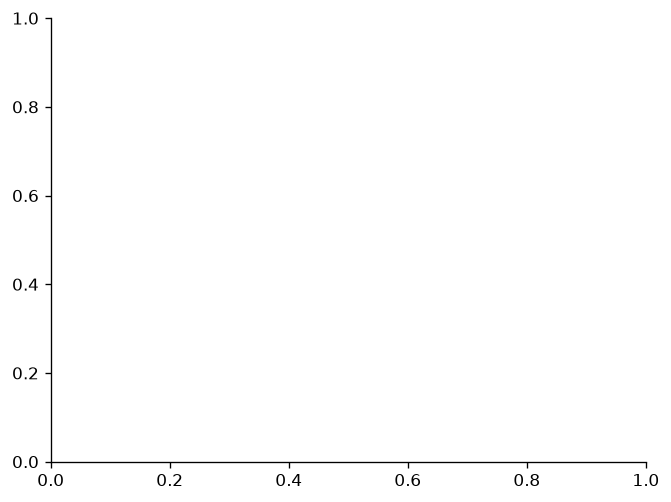

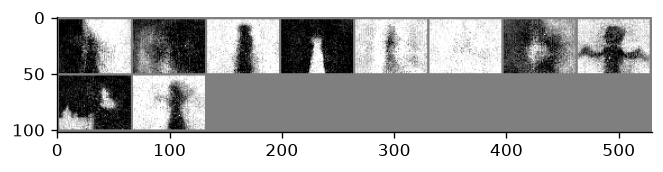

In [136]:
points = 10

ps = torch.randn(points, img_h * img_w * chanels)
print(ps.shape)
with torch.no_grad():
    imgs = model.inverse(ps)
imgs = imgs.reshape(points, chanels, img_h, img_w)

fig, ax = plt.subplots()

print(imgs.shape)
img = torchvision.utils.make_grid(imgs)
print(img.shape)

fig, ax = plt.subplots()
img = img / 2 + 0.5     # unnormalize
npimg = img.numpy()
ax.imshow(np.transpose(npimg, (1, 2, 0)))
# plt.show()


In [162]:
spline, u = make_splprep(ps.numpy().transpose(), s=0, bc_type="periodic")

In [151]:
ps.numpy().shape

(10, 3072)

In [163]:
spline(0.5)

array([-0.42502291, -0.61538593, -0.95633985, ...,  0.72491306,
       -0.73347859,  0.01369158], shape=(3072,))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9979837..1.4102616].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9979837..1.4102616].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9919841..1.4094806].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9848417..1.4086478].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9763042..1.4069985].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9700365..1.4052103].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.965245

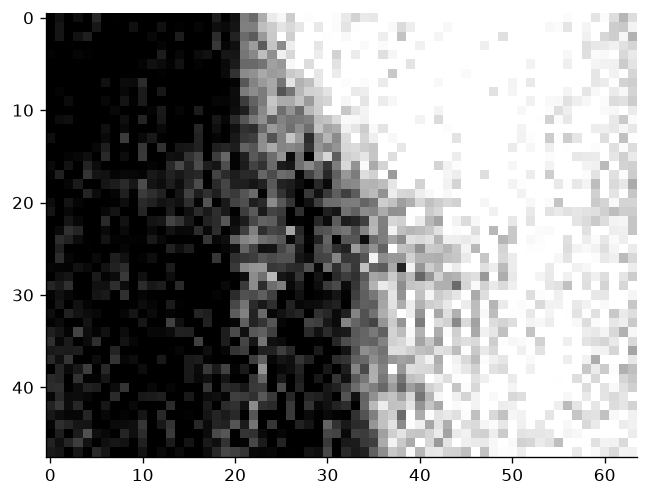

In [164]:
fig, ax = plt.subplots()

def update(alpha: float):
    ax.clear()

    p = spline(alpha)
    p = torch.tensor(p, dtype=torch.float32)
    # print(p.shape)

    with torch.no_grad():
        img = model.inverse(p.reshape(1, img_w * img_h * chanels))
    img = img.reshape(chanels, img_h, img_w)
    img = torchvision.utils.make_grid(img)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    return []

anim = FuncAnimation(fig=fig, func=update, frames=np.linspace(0, 1, 1200), interval=20)

# plt.close(fig)
# plt.show()
anim.save("aboba.gif")

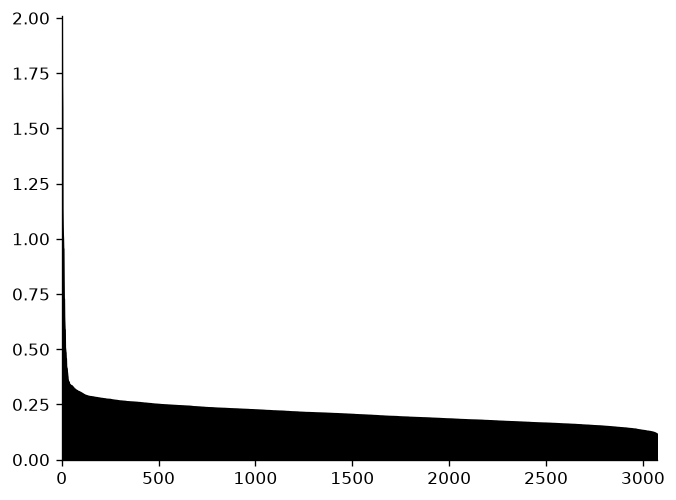

In [134]:
importance = model.log_scale.numpy(force=True)
importance = (1 / np.exp(importance))
importance.sort()
importance = importance[::-1]
importance
fig, ax = plt.subplots()

# ax.plot(range(importance.shape[0]), importance, alp)

ax.fill_between(range(importance.shape[0]), importance, 0, color="#000000")

ax.set_ylim(0, importance[0])
ax.set_xlim(0, importance.shape[0])

fig.savefig("gallary/bad_apple.png")